In [1]:
from importlib import reload
import torch
import numpy as np
import time
import copy
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
CUDA_LAUNCH_BLOCKING=1
cupy_device = device.index if device.type == "cuda" else 0
def ana_S(y,x_left,x_right,y_below,y_upper,center,r):
    y0=y[:,0]
    y1=y[:,1]
    return 1.1*np.exp(-200*((y0-0.01)**2+(y1-0.12)**2))-100*(y1**2-y0**2)*np.exp(-90*(y0**2+y1**2))




cuda:1


In [ ]:
reload(mea_2d)
reload(generate_data)
reload(inverse_solver)
reload(mesh)
reload(net_2d)


## 1

In [3]:
a = 0.6  # V_0 = [-a, a] × [-a, a]
R = 0.5  # Radius of measurement circle
rho = 0.6  # Radius for artificial Cauchy data
lam = 1e-3  # Parameter λ
k_star = lam * 2*np.pi / a #k*
noise_level=0.05

N = 2 * int(noise_level**(-1/3)+1) #N

l = []
for i in range(N+1):        # i from 0 to 6
    for j in range(i, N+1): # j from i to 6
        l.append([i, j])

vector_l=np.array(l)
norm_l=np.linalg.norm(vector_l,axis=1)
norm_l[0]=10**(-3)
K_N=10*np.pi/3*norm_l
tau_x_min,tau_x_max,tau_y_min,tau_y_max=-0.3,0.3,-0.3,0.3
number_gene=200
eps=0.05
batch_number_rec_mea,mea=2,1
kk=K_N

In [ ]:
reload(generate_data)


## Generate data

In [5]:
reload(generate_data)

<module 'synthetic_data' from '/data1/hxw-b25/MA-RFM/Ex4.2/../main_code/2d/synthetic_data.py'>

In [6]:
b_n=100
N_m=100
N_m_inv=40
points_b_R=mea_2d.p_b_circle(alpha=1,radius=0.5,n=b_n,temp=False) # Collect data on boundary Gamma
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
number_gene=200
eps=0.05
batch_number_rec_mea,mea=2,1
rho=0.6
S_int_true1, F_mea_b_R, F_mea_db_R= generate_data.boundary_data_rec(kk, number_gene, points_b_R, ana_S,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],eps,mea,batch_number_rec_mea,device,cupy_device)
points_b_rho=mea_2d.p_b_circle(alpha=1,radius=rho,n=N_m_inv,temp=False) # Collect data on boundary Gamma
n_trun=60
v_rho,dv_rho=generate_data.dir_neu(N_m,N_m_inv,kk,R,rho,n_trun,F_mea_b_R) 
V_rho=inverse_solver.F(v_rho,dv_rho) # Verified
R_m=20


In [7]:
Nx,Ny=1,1
Ix,Iy=5,5  # Number of grid cells in the x direction
nx,ny=5,5  # Gauss points per cell in the x direction
cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b_rho) # Create the initial grid
initial_cells=copy.deepcopy(cells) # Make a copy

In [13]:
import time # Closely related to the random seed and can even affect convergence. Pretraining can help filter poor random seeds, but it has a computational cost.
import numpy as np
# np.random.seed(2)
# torch.manual_seed(2)
# torch.cuda.manual_seed_all(2)
torch.backends.cudnn.deterministic = True
M=3200
af="sin"   
R_m=20
models0 = net_2d.pre_define(Nx,Ny,M,R_m,"sin",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


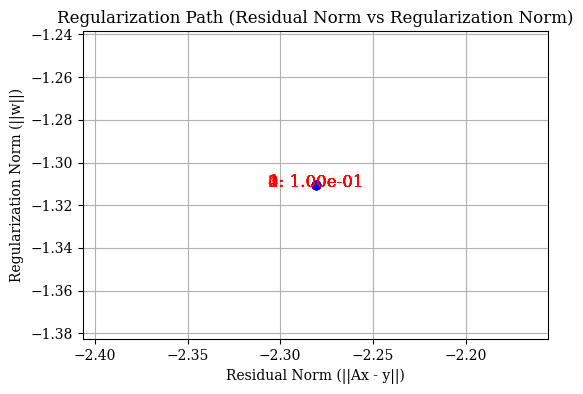

第 0 次迭代的train误差：
第 0 次迭代的泛化误差：
S_l_inf= 0.1313331002137594 S_L_2= 0.00197564871397653 S_l_2= 0.013054911838837278


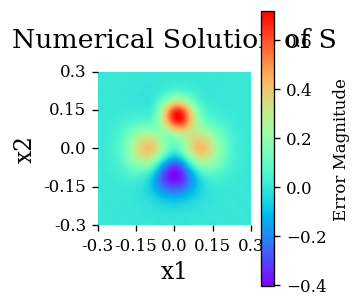

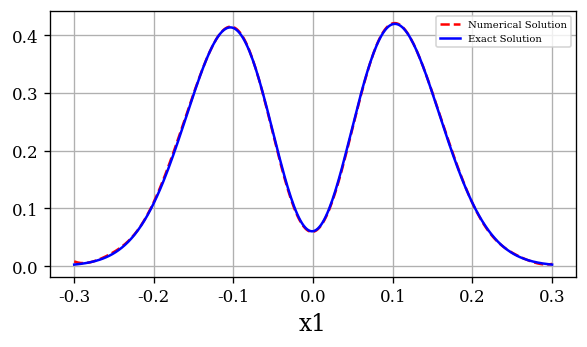

第 0 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


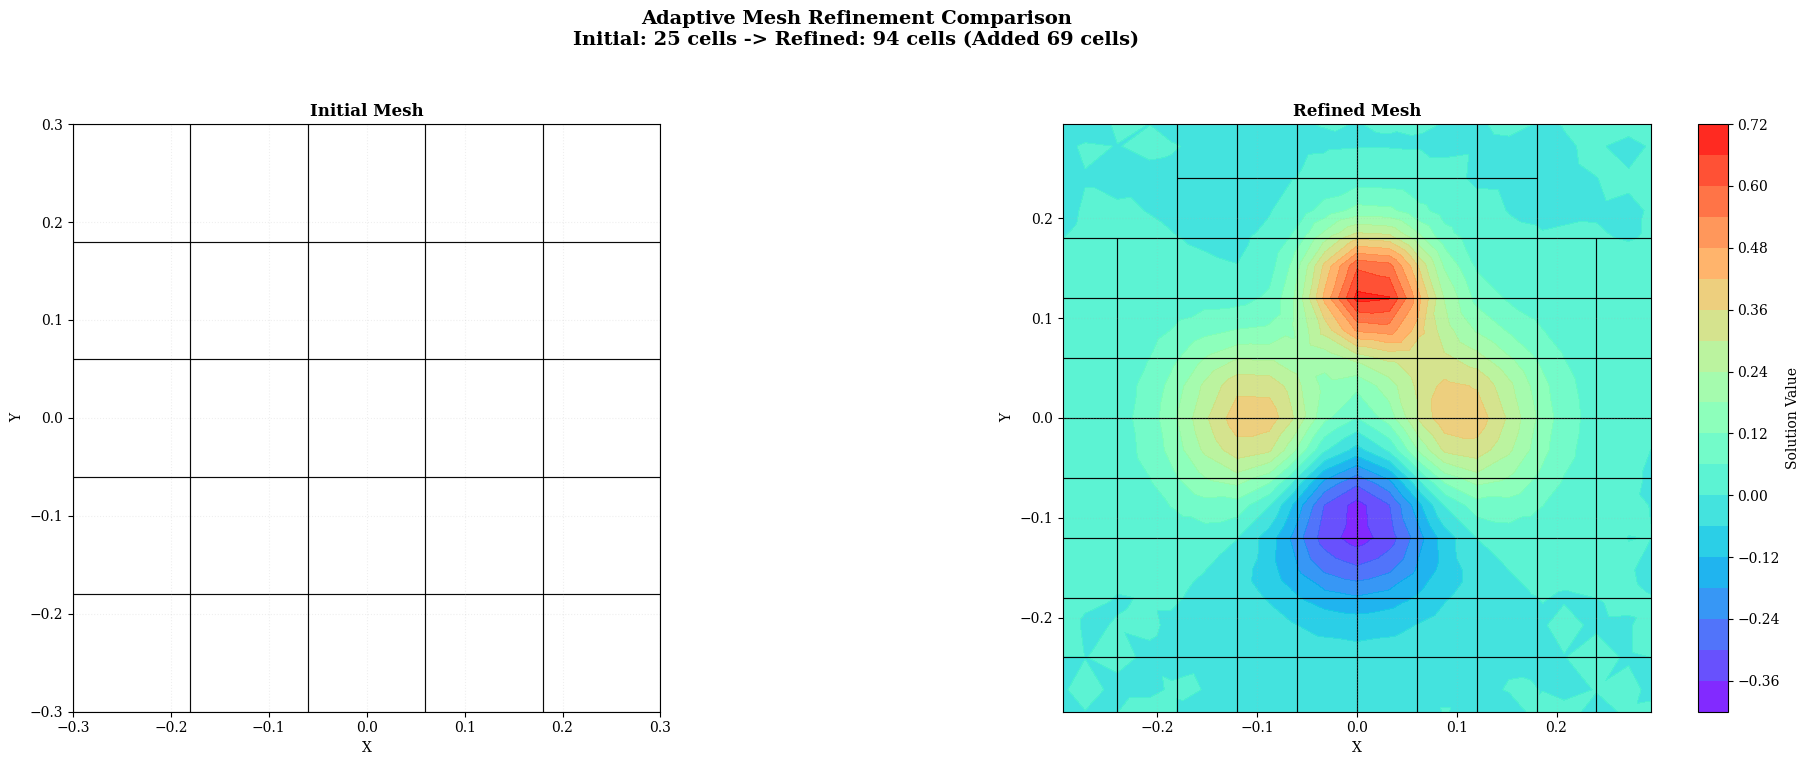

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


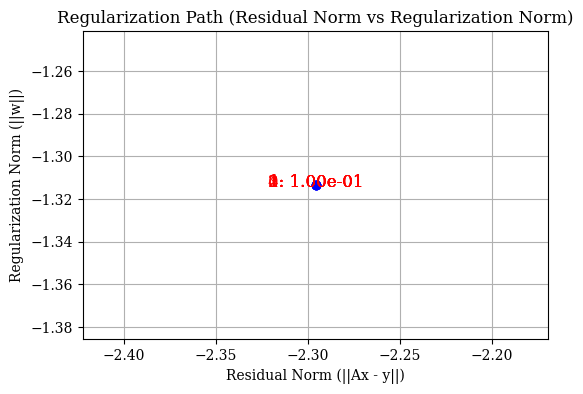

第 1 次迭代的train误差：
第 1 次迭代的泛化误差：
S_l_inf= 0.12917451811564087 S_L_2= 0.0012232209278213188 S_l_2= 0.008082935624717423


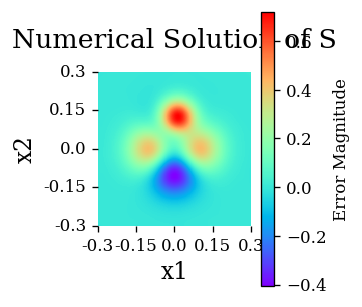

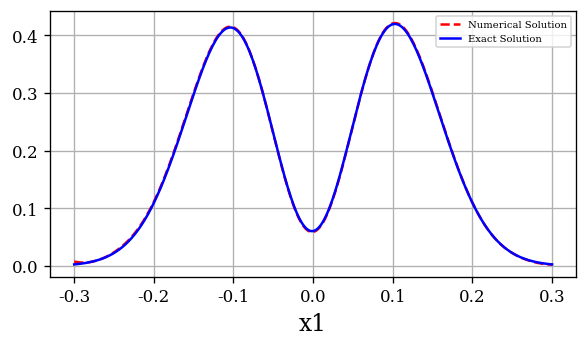

第 1 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


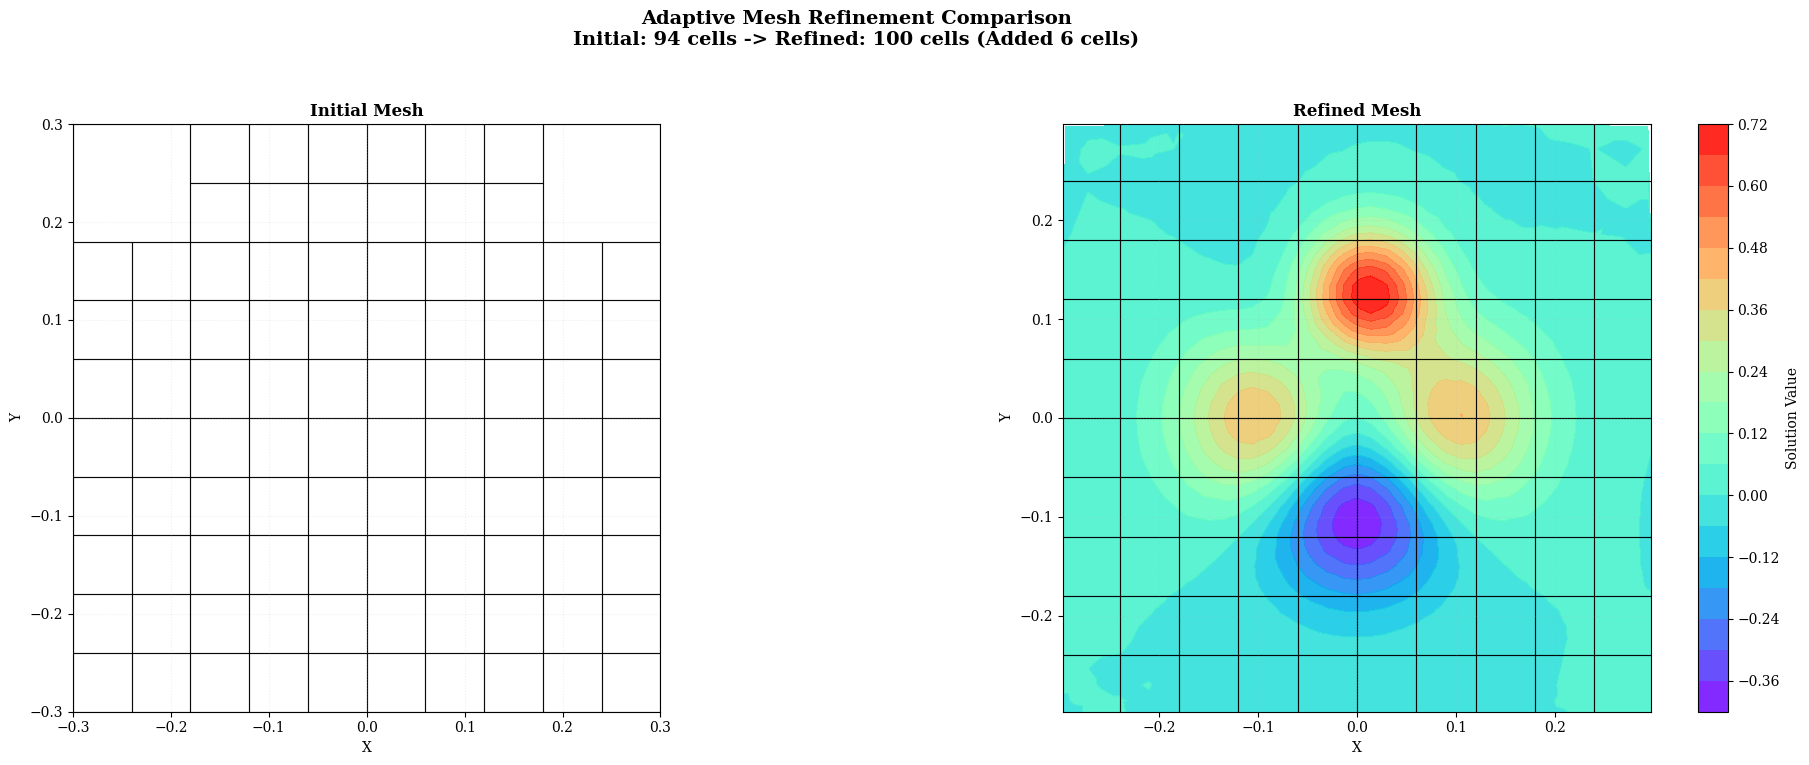

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


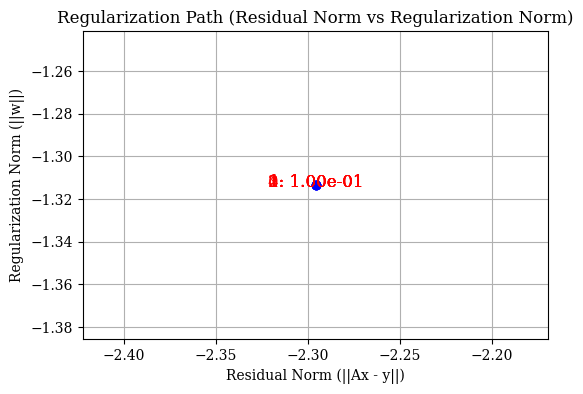

第 2 次迭代的train误差：
第 2 次迭代的泛化误差：
S_l_inf= 0.1232170573666428 S_L_2= 0.0012215012665090172 S_l_2= 0.008071572254971609


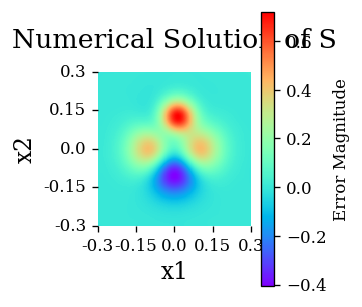

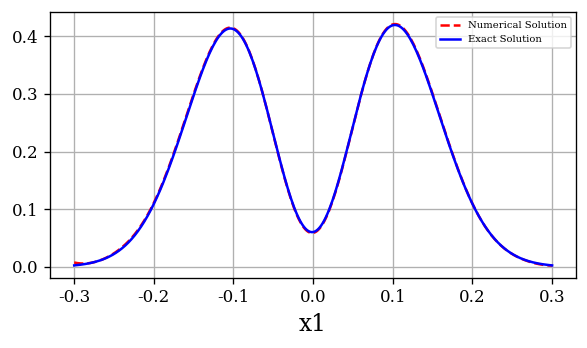

在第 2 次迭代结束


In [14]:
iter_int= 5
Ix,Iy=5,5  # Number of grid cells in the x direction
delta=10**(-3)
nx=5
lamb_regu=np.logspace(-1,-1,5)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="sin"
refine_threshold_S=1/100
refine_threshold_grad=1/300
# using main_fix.ada_int_fix
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_l2,S_num_store=main.ada_int(iter_int,delta,cells,nx,models0,M,af,kk,V_rho,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],ana_S,points_b_rho,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,current_maxiter,max_level)


In [10]:
# Save the models1 model
torch.save(models0,f"./IARFM/N_m=100/models0_55_3200_{point_number[-1]}_10-2.pth")


In [11]:
np.save("./IARFM/N_m=100/S_num_store",S_num_store)


In [12]:
import pickle # Import the pickle module
output_pickle_file = "./IARFM/N_m=100/cells_store_last.pkl"
with open(output_pickle_file, 'wb') as f: # 'wb' for write binary
    pickle.dump(cells_store[-1], f)